# 05 — The numbers

Five things to measure, each with error bars.

**With 40 cases, "88%" is misleading** — it sounds precise and it isn't. Report
`0.88 [0.74, 0.96]` instead.

Reads whatever notebook 04 wrote. Set `RUN_NAME` below to `"smoke"` while iterating and
`"full"` once the full experiment has been run.

In [1]:
import os, sys, json, re
from pathlib import Path

# works locally and in Colab
for candidate in (Path.cwd(), Path.cwd().parent, Path("/content/pa-appeal")):
    if (candidate / "data").exists():
        os.chdir(candidate)
        break
ROOT = Path.cwd()
print("working from:", ROOT)


working from: /content/pa-appeal


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

RUN_NAME = "full"          # <- change to "full" after running 04 with RUN_FULL = True

RESULT_DIR = Path("data/results") / RUN_NAME
runs = {p.stem: json.load(open(p)) for p in sorted(RESULT_DIR.glob("*.json"))}

if not runs:
    raise FileNotFoundError(
        f"No result files in {RESULT_DIR}. Run notebook 04 first with "
        f"RUN_FULL = {RUN_NAME == 'full'}.")

ORDER = ["row0_context_only", "row1_naive", "row2_structure",
         "row3_hybrid", "row4_rerank", "row5_full"]
AVAILABLE = [n for n in ORDER if n in runs]
MAIN = "row5_full" if "row5_full" in runs else AVAILABLE[-1]

print(f"run: {RUN_NAME}   (main config for the detailed plots: {MAIN})")
for name in AVAILABLE:
    rows = runs[name]["rows"]
    print(f"  {name:<20} {len(rows):>5} decisions   "
          f"{len({r['case_id'] for r in rows}):>2} cases   "
          f"model={runs[name].get('model')}")

run: full   (main config for the detailed plots: row5_full)
  row0_context_only      239 decisions   40 cases   model=gemini-3.1-flash-lite
  row1_naive             239 decisions   40 cases   model=gemini-3.1-flash-lite
  row2_structure         239 decisions   40 cases   model=gemini-3.1-flash-lite
  row3_hybrid            239 decisions   40 cases   model=gemini-3.1-flash-lite
  row4_rerank            239 decisions   40 cases   model=gemini-3.1-flash-lite
  row5_full              239 decisions   40 cases   model=gemini-3.1-flash-lite


## Error bars

Wilson for proportions (correct at small n, unlike the usual formula). Bootstrap for F1 —
resample the decisions 1000 times and look at the spread.

In smoke mode there are only a handful of decisions, so every interval will be nearly the
full width of the axis. That is the interval telling the truth, not a bug.

In [3]:
import math

def wilson(successes, n, z=1.96):
    """95% interval for a proportion."""
    if n == 0:
        return (float("nan"),) * 3
    p = successes / n
    denom  = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    half   = z * math.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return p, max(0, centre - half), min(1, centre + half)

def bootstrap(items, stat, n_resamples=1000, seed=0):
    if not items:
        return (float("nan"),) * 3
    rng = np.random.default_rng(seed)
    n = len(items)
    draws = [stat([items[i] for i in rng.integers(0, n, n)]) for _ in range(n_resamples)]
    lo, hi = np.percentile(draws, [2.5, 97.5])
    return stat(items), float(lo), float(hi)

def fmt(point, lo, hi):
    if any(math.isnan(v) for v in (point, lo, hi)):
        return "—"
    return f"{point:.2f} [{lo:.2f}, {hi:.2f}]"

print(fmt(*wilson(35, 40)))

0.88 [0.74, 0.95]


## The five measurements

Field names come straight from the rows notebook 04 writes:

| row field | what it is |
|---|---|
| `gold` | the frozen oracle's label |
| `predicted_raw` | what the model said |
| `predicted_final` | after abstention, when the config enables it |
| `quote_status` | `supported` / `close` / `wrong_doc` / `made_up` / `empty`, by string match |
| `retrieval_rank` | 1-based rank of the criterion's passage, `None` if never retrieved |

In [4]:
from sklearn.metrics import f1_score, confusion_matrix

LABELS  = ["met", "unmet", "insufficient_evidence"]
ABSTAIN = "insufficient_evidence"

def macro_f1(rows, field="predicted_final"):
    return f1_score([r["gold"] for r in rows], [r[field] for r in rows],
                    labels=LABELS, average="macro", zero_division=0)

def summarise(run):
    rows = run["rows"]
    n    = len(rows)
    cfg  = run["config"]

    # Row 0 puts the whole of L33718 into one pseudo-chunk, so every criterion "ranks"
    # first by construction. That is not a retrieval result, so it is not reported.
    if cfg["retrieval"] is None:
        found = "—"
    else:
        found = fmt(*wilson(sum(r["retrieval_rank"] is not None for r in rows), n))

    answered = [r for r in rows if r["predicted_final"] != ABSTAIN]
    return [
        found,
        fmt(*bootstrap(rows, macro_f1)),
        fmt(*wilson(sum(r["quote_status"] == "supported"   for r in rows), n)),
        # from_record and made_up are different failures and must not be added together.
        # from_record = real text copied out of the patient record, wrong corpus.
        # made_up     = text that appears in no policy and no record. Actual fabrication.
        fmt(*wilson(sum(r["quote_status"] == "from_record" for r in rows), n)),
        fmt(*wilson(sum(r["quote_status"] == "made_up"     for r in rows), n)),
        fmt(*wilson(sum(r["predicted_final"] == ABSTAIN  for r in rows), n)),
        fmt(*wilson(sum(r["gold"] == r["predicted_final"] for r in answered), len(answered))),
    ]

## The table

In [5]:
HEAD  = ["config", "found rule", "F1", "quotes real", "from record", "made up",
         "abstained", "acc. answered"]
WIDTH = [20, 19, 19, 19, 19, 19, 19, 19]

print(" | ".join(h.ljust(w) for h, w in zip(HEAD, WIDTH)))
print("-" * (sum(WIDTH) + 3 * len(WIDTH)))
for name in AVAILABLE:
    cells = [name] + summarise(runs[name])
    print(" | ".join(str(c).ljust(w) for c, w in zip(cells, WIDTH)))

print()
print("found rule: row 1 chunks by size, so its column asks whether the rule's sentence")
print("  appears anywhere inside a retrieved 512-word block. Rows 2-5 require the exact")
print("  criterion chunk. Row 1's number is the easier test and is not directly")
print("  comparable with the rows below it.")

# then paste this into README.md

config               | found rule          | F1                  | quotes real         | from record         | made up             | abstained           | acc. answered      
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
row0_context_only    | —                   | 0.86 [0.77, 0.93]   | 0.87 [0.82, 0.91]   | 0.00 [0.00, 0.02]   | 0.05 [0.03, 0.09]   | 0.05 [0.03, 0.09]   | 0.96 [0.93, 0.98]  
row1_naive           | 0.34 [0.28, 0.40]   | 0.81 [0.73, 0.88]   | 0.89 [0.84, 0.92]   | 0.00 [0.00, 0.02]   | 0.02 [0.01, 0.04]   | 0.10 [0.07, 0.15]   | 0.96 [0.93, 0.98]  
row2_structure       | 0.65 [0.59, 0.71]   | 0.91 [0.83, 0.97]   | 0.95 [0.91, 0.97]   | 0.00 [0.00, 0.02]   | 0.02 [0.01, 0.05]   | 0.05 [0.03, 0.08]   | 0.96 [0.93, 0.98]  
row3_hybrid          | 0.67 [0.61, 0.73]   | 0.79 [0.71, 0.87]   | 0.82 [0.77, 0.87]   | 0.00 [0.00, 0.02]   | 0.00 [0.00,

## What abstention actually changed

`predicted_raw` is what the model said; `predicted_final` is what survived quote
verification. Only configs with `abstain: True` differ between the two.

In [6]:
print(f"{'config':<20} {'raw F1':>8} {'final F1':>9} {'forced abstentions':>20}")
for name in AVAILABLE:
    rows = runs[name]["rows"]
    forced = sum(r["predicted_raw"] != ABSTAIN and r["predicted_final"] == ABSTAIN
                 for r in rows)
    print(f"{name:<20} {macro_f1(rows, 'predicted_raw'):>8.2f} "
          f"{macro_f1(rows, 'predicted_final'):>9.2f} {forced:>20}")

config                 raw F1  final F1   forced abstentions
row0_context_only        0.86      0.86                    0
row1_naive               0.81      0.81                    0
row2_structure           0.91      0.91                    0
row3_hybrid              0.79      0.79                    0
row4_rerank              0.90      0.90                    0
row5_full                0.90      0.90                    0


## Confusion matrix

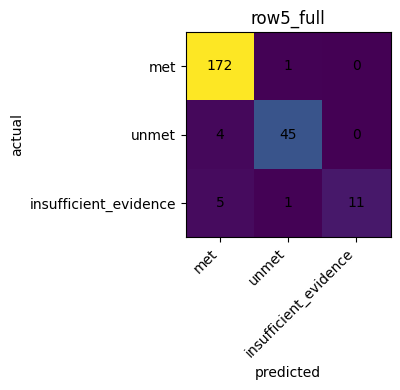

In [7]:
rows = runs[MAIN]["rows"]
cm = confusion_matrix([r["gold"] for r in rows],
                      [r["predicted_final"] for r in rows], labels=LABELS)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm)
ax.set_xticks(range(3), LABELS, rotation=45, ha="right")
ax.set_yticks(range(3), LABELS)
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center")
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title(MAIN)
plt.tight_layout()

## Risk–coverage curve

Sweep a threshold: how much it answers, against how wrong it is on what it answered. The
shape of this curve is the entire argument for letting it abstain.

**Two signals could order the decisions, and they are not equally trustworthy.**

1. **`quote_status` — objective.** Produced by string matching against the policy text,
   not by the model. This is the primary curve and the one to quote.
2. **`model_reported_confidence` — self-reported and uncalibrated.** An LLM's stated
   confidence is not a probability; it is generated text. It is plotted only as an
   exploratory comparison. Do not present it as a reliability estimate, and do not use it
   to decide anything. If the two curves disagree, the objective one is the finding.

The curve uses `predicted_raw`, because the question it asks is whether a signal can
separate the model's right answers from its wrong ones *before* abstention is applied.

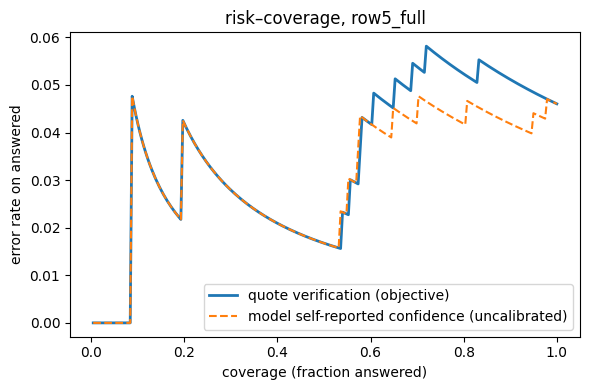

In [8]:
# higher = more trustworthy
# Ranked by how much the quote actually supports the decision. wrong_doc still cited
# real policy language and only mis-attributed it; from_record cited the patient's own
# paperwork as though it were a rule, which is further from evidence of coverage.
VERIFICATION_ORDER = {"supported": 5, "close": 4, "wrong_doc": 3,
                      "from_record": 2, "made_up": 1, "empty": 0}

def risk_coverage(rows, key):
    scored  = sorted(rows, key=key, reverse=True)
    correct = np.array([r["gold"] == r["predicted_raw"] for r in scored], dtype=float)
    k       = np.arange(1, len(scored) + 1)
    return k / len(scored), 1 - np.cumsum(correct) / k

rows = runs[MAIN]["rows"]
fig, ax = plt.subplots(figsize=(6, 4))

cov, err = risk_coverage(rows, lambda r: VERIFICATION_ORDER.get(r["quote_status"], 0))
ax.plot(cov, err, label="quote verification (objective)", linewidth=2)

# Exploratory only -- see the note above. Absent if the run predates the schema change.
conf = [r.get("model_reported_confidence") for r in rows]
if any(c is not None for c in conf):
    cov2, err2 = risk_coverage(rows, lambda r: (r.get("model_reported_confidence") or 0.0))
    ax.plot(cov2, err2, "--", label="model self-reported confidence (uncalibrated)")

ax.set_xlabel("coverage (fraction answered)")
ax.set_ylabel("error rate on answered")
ax.set_title(f"risk–coverage, {MAIN}")
ax.legend()
plt.tight_layout()

## Is the self-reported confidence worth anything?

Don't take the "uncalibrated" warning on trust — measure it. The number that matters is
the **gap between mean confidence when the model is right and when it is wrong**. If that
gap is near zero, the confidence carries no information about correctness and the dashed
exploratory curve above is noise, however smooth it looks.

Compare it against `quote_status`, which is not self-reported: it comes from matching the
quote against the policy text.

In [ ]:
conf_rows = [r for r in rows if r.get("model_reported_confidence") is not None]

if not conf_rows:
    print("no model_reported_confidence in this run")
else:
    vals = [r["model_reported_confidence"] for r in conf_rows]
    print(f"confidence over {len(vals)} decisions: "
          f"min {min(vals):.2f}  max {max(vals):.2f}  mean {sum(vals)/len(vals):.3f}")

    right = [r["model_reported_confidence"] for r in conf_rows
             if r["gold"] == r["predicted_raw"]]
    wrong = [r["model_reported_confidence"] for r in conf_rows
             if r["gold"] != r["predicted_raw"]]

    if right and wrong:
        mr, mw = sum(right) / len(right), sum(wrong) / len(wrong)
        print(f"  when correct (n={len(right):>3}): {mr:.3f}")
        print(f"  when wrong   (n={len(wrong):>3}): {mw:.3f}")
        print(f"  gap                  : {mr - mw:+.3f}")
        if abs(mr - mw) < 0.05:
            print("  -> the model is about as confident when wrong as when right.")
            print("     It carries no usable signal. Report it as a negative result;")
            print("     do not use it to rank, threshold or abstain.")
    else:
        print("  need both correct and incorrect decisions to compare")

    # The objective signal, measured the same way, across EVERY config -- MAIN alone may
    # have no failed quotes left, which hides the interesting rows.
    print("\naccuracy by quote_status (objective, not self-reported):")
    print(f"  {'config':<20} " + " ".join(f"{s:>16}" for s in
          ("supported", "made_up", "empty")))
    for name in AVAILABLE:
        rws = runs[name]["rows"]
        cells_ = []
        for status in ("supported", "made_up", "empty"):
            sub = [r for r in rws if r["quote_status"] == status]
            cells_.append(f"{sum(r['gold'] == r['predicted_raw'] for r in sub) / len(sub):.2f}"
                          f" (n={len(sub)})" if sub else "-")
        print(f"  {name:<20} " + " ".join(f"{c:>16}" for c in cells_))
    print("\n  A config that is accurate on rows whose quote could NOT be verified is")
    print("  reaching the right answer with an invented citation. Abstaining on those")
    print("  rows buys trustworthy citations at the cost of accuracy -- that trade is")
    print("  the whole argument, and it should be stated as a trade, not a free win.")
    print("\nIf accuracy separates across these rows but not across confidence, that is")
    print("the argument for verifying quotes rather than asking the model how sure it is.")

## Diagnostics

Where the errors actually live. With `n = 40` the headline table hides almost everything,
so this is usually the more useful cell.

In [ ]:
rows = runs[MAIN]["rows"]

print("quote status, every config:")
for name in AVAILABLE:
    c = Counter(r["quote_status"] for r in runs[name]["rows"])
    total = sum(c.values())
    parts = "  ".join(f"{k}={c[k]}" for k in
                      ("supported", "close", "wrong_doc", "from_record", "made_up", "empty")
                      if c[k])
    print(f"  {name:<20} {parts}")

sections = Counter(r.get("quote_record_section") for r in rows
                   if r.get("quote_record_section"))
if sections:
    print("\nwhen the model quoted the record instead of the policy, it quoted:")
    for sec, k in sections.most_common():
        note = "   <- the payer's own paraphrase of a rule" if sec == "denial_letter" else ""
        print(f"  {sec:<16} {k:>4}{note}")

print()
omitted = sum(r["model_omitted"] for r in rows)
print(f"criteria the model was asked for but did not return: {omitted}/{len(rows)}")

missed = sum(r["retrieval_rank"] is None for r in rows)
print(f"criterion passage never retrieved:                   {missed}/{len(rows)}")
print(f"distinct chunks retrieved across all cases:          "
      f"{len({c for r in rows for c in r['retrieved_chunk_ids']})}")

# Three kinds of document, not two. Calling everything-but-L33718 a decoy was wrong:
# A52467 is the PAP policy article and the two NCDs are the national CPAP and sleep-test
# rules, so retrieving them is reasonable. Only the eight unrelated equipment LCDs are
# there to be wrong answers, and only those tell you whether retrieval is being fooled.
TARGET     = "L33718"
SUPPORTING = {"A52467", "A55426", "NCD240.4", "NCD240.4.1"}

def doc_class(doc):
    if doc == TARGET:
        return "target"
    return "supporting" if doc in SUPPORTING else "decoy"

counts = Counter(d for r in rows for d in r["retrieved_doc_ids"])
total  = sum(counts.values())

print("\nretrieved documents:")
for doc, k in counts.most_common():
    print(f"  {doc:<12} {k:>5}   {doc_class(doc)}")

by_class = Counter()
for doc, k in counts.items():
    by_class[doc_class(doc)] += k

print("\n  share of retrieved context:")
for cls in ("target", "supporting", "decoy"):
    share = by_class[cls] / total if total else 0
    print(f"    {cls:<12} {by_class[cls]:>5}   {share:.0%}")
print("\n  decoys are the eight unrelated equipment LCDs; a high decoy share means")
print("  retrieval is being pulled away from the policy that actually governs the case.")

# macro-F1 averages over all three labels, so inside a bucket that contains only two of
# them it is capped at 2/3 -- which looks like a bad score and is not one. Report accuracy
# per bucket and show the cap alongside, so 0.67 is never mistaken for a finding.
print("\nby bucket:")
print(f"  {'bucket':<14} {'n':>4} {'classes':>8} {'accuracy':>9} {'macro-F1':>9}  {'':<12}")
for b in sorted({r["bucket"] for r in rows}):
    sub = [r for r in rows if r["bucket"] == b]
    classes = {r["gold"] for r in sub}
    acc = sum(r["gold"] == r["predicted_final"] for r in sub) / len(sub)
    cap = len(classes) / len(LABELS)
    note = "" if len(classes) == len(LABELS) else f"  <- F1 capped at {cap:.2f}"
    print(f"  {b:<14} {len(sub):>4} {len(classes):>8} {acc:>9.2f} {macro_f1(sub):>9.2f}{note}")

print("\naccuracy by criterion:")
for cid in sorted({r["criterion_id"] for r in rows}):
    sub = [r for r in rows if r["criterion_id"] == cid]
    ok  = sum(r["gold"] == r["predicted_final"] for r in sub)
    print(f"  {cid:<22} {ok}/{len(sub)}")

## Sensitivity: the alternative-route disagreement

B1 and B2 are alternative routes to the same coverage decision. The oracle in notebook 02
scores each **as written**, so a patient with AHI 26 has B1 met and B2 unmet — B2's 5–14
range simply is not satisfied. The model reads the same situation as *"this criterion is
not applicable because the patient met B1"* and, having no not-applicable label, returns
insufficient_evidence.

Both readings are defensible. Roughly half of all `unmet` decisions in the 40-case set are
this pattern, so it is worth knowing how much of the headline number it drives.

**The oracle is frozen and is not edited here.** The table above remains the number of
record. What follows is a sensitivity analysis: the same metrics with alternative-route
decisions excluded, reported separately and never substituted for the primary result.
If the two differ a lot, both belong in the README.

In [11]:
def alt_route_rows(rows):
    """Decisions where gold=unmet only because the patient took the OTHER route."""
    gold_by_case = {}
    for r in rows:
        gold_by_case.setdefault(r["case_id"], {})[r["criterion_id"]] = r["gold"]

    flagged = set()
    for i, r in enumerate(rows):
        g = gold_by_case[r["case_id"]]
        other = {"B1": "B2", "B2": "B1"}.get(r["criterion_id"])
        if other and r["gold"] == "unmet" and g.get(other) == "met":
            flagged.add(i)
    return flagged


print(f"{'config':<20} {'primary F1':>11} {'excl. alt-route':>16} {'n excluded':>11}")
print("-" * 62)
for name in AVAILABLE:
    rws = runs[name]["rows"]
    flagged = alt_route_rows(rws)
    kept = [r for i, r in enumerate(rws) if i not in flagged]
    primary = macro_f1(rws)
    excl = macro_f1(kept) if kept else float("nan")
    # If excluding these empties a whole gold class, macro-F1 scores that class 0 and the
    # two columns stop being comparable. On the 4-case smoke set every unmet gold IS an
    # alternative-route decision, so the right-hand column is capped at 0.67 by
    # construction. With 40 cases there are 25 unmet golds that are not alternative-route,
    # and the comparison becomes meaningful.
    lost = set(r["gold"] for r in rws) - set(r["gold"] for r in kept)
    flag = f"   <- excluding these removed the '{'/'.join(sorted(lost))}' class" if lost else ""
    print(f"{name:<20} {primary:>11.2f} {excl:>16.2f} {len(flagged):>11}{flag}")

# how the model actually labelled those decisions
rws = runs[MAIN]["rows"]
flagged = alt_route_rows(rws)
if flagged:
    print(f"\nwhat the model said on the {len(flagged)} alternative-route decisions ({MAIN}):")
    for lab, k in Counter(rws[i]["predicted_raw"] for i in flagged).most_common():
        print(f"  {lab:<24} {k}")
    print("\n  a sample of its reasoning:")
    for i in sorted(flagged)[:3]:
        print(f"    {rws[i]['case_id']} {rws[i]['criterion_id']}: {rws[i]['reasoning'][:100]}")
else:
    print("\nno alternative-route decisions in this run")

print("\nRemaining errors after excluding them, by criterion:")
kept = [r for i, r in enumerate(rws) if i not in flagged]
wrong = Counter(r["criterion_id"] for r in kept if r["gold"] != r["predicted_final"])
print("  none" if not wrong else
      "\n".join(f"  {c:<22} {k}" for c, k in wrong.most_common()))

config                primary F1  excl. alt-route  n excluded
--------------------------------------------------------------
row0_context_only           0.86             0.89          24
row1_naive                  0.81             0.92          24
row2_structure              0.91             0.90          24
row3_hybrid                 0.79             0.92          24
row4_rerank                 0.90             0.90          24
row5_full                   0.90             0.90          24

what the model said on the 24 alternative-route decisions (row5_full):
  unmet                    21
  met                      3

  a sample of its reasoning:
    case_001 B2: The patient's AHI is 26.5, which is outside the 5-14 range required for this criterion.
    case_002 B2: The patient's AHI of 31.2/hr does not fall within the 5-14 range required for this criterion.
    case_003 B2: The patient's AHI of 20.1 is outside the 5-14 range required for this criterion.

Remaining errors after excl

## Handwritten vs templated

If the model does much worse on cases written by hand, the templates were too easy and the
README has to say so.

In [12]:
rows = runs[MAIN]["rows"]
hand = [r for r in rows if r["hand_written"]]
tmpl = [r for r in rows if not r["hand_written"]]

if not hand:
    print(f"No handwritten cases: all {len(tmpl)} decisions come from generated text.")
    print("Every field is phrased from a small bank, so a model could be matching phrasing")
    print("rather than reading the record, and nothing here would reveal it.")
    print("Either rewrite some cases by hand in notebook 02 (set hand_written = True),")
    print("or state this in the README limitations. Do not quote these numbers without it.")
else:
    print("handwritten:", fmt(*bootstrap(hand, macro_f1)), f"(n={len(hand)})")
    print("templated:  ", fmt(*bootstrap(tmpl, macro_f1)), f"(n={len(tmpl)})")

No handwritten cases: all 239 decisions come from generated text.
Every field is phrased from a small bank, so a model could be matching phrasing
rather than reading the record, and nothing here would reveal it.
Either rewrite some cases by hand in notebook 02 (set hand_written = True),
or state this in the README limitations. Do not quote these numbers without it.


In [13]:
# save the /content/pa-appeal/data/results/RUN_NAME directory to a zip file for sharing


import shutil
shutil.make_archive('results_final', 'zip', f'/content/pa-appeal/data/results/{RUN_NAME}')



'/content/pa-appeal/results_final.zip'